<a href="https://colab.research.google.com/github/AdenFatima/neurofive-ml-track/blob/main/task9_imbalanced_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 9: Handling Imbalanced & Messy Real-World Data

In [1]:
!pip install imbalanced-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [2]:
# 1. Load the Telco Churn Dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Basic Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

/tmp/ipykernel_1652/3135239305.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


/tmp/ipykernel_1652/1557242863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


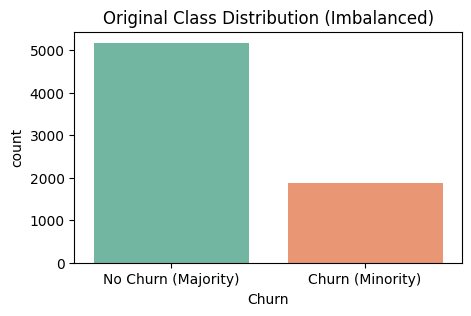

In [3]:
# 2. Visualize Original Class Imbalance
plt.figure(figsize=(5, 3))
sns.countplot(x=y, palette='Set2')
plt.title("Original Class Distribution (Imbalanced)")
plt.xticks([0, 1], ['No Churn (Majority)', 'Churn (Minority)'])
plt.show()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# ==========================================
# 3. TRAIN ORIGINAL MODEL (IMBALANCED)
# ==========================================
model_imb = LogisticRegression(max_iter=5000, solver='liblinear')
model_imb.fit(X_train, y_train)
preds_imb = model_imb.predict(X_test)

print("--- BEFORE: CLASSIFICATION REPORT (IMBALANCED DATA) ---")
print(classification_report(y_test, preds_imb))

--- BEFORE: CLASSIFICATION REPORT (IMBALANCED DATA) ---
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.70      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409




Applying SMOTE to balance the training data...



/tmp/ipykernel_1652/479398449.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='Set2')


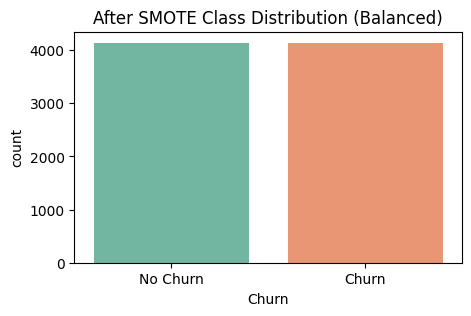

In [5]:
# ==========================================
# 4. FIX IMBALANCE WITH SMOTE
# ==========================================
print("\nApplying SMOTE to balance the training data...\n")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Visualize Balanced Data
plt.figure(figsize=(5, 3))
sns.countplot(x=y_train_smote, palette='Set2')
plt.title("After SMOTE Class Distribution (Balanced)")
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

In [6]:
# ==========================================
# 5. TRAIN NEW MODEL ON SMOTE DATA
# ==========================================
model_smote = LogisticRegression(max_iter=5000, solver='liblinear')
model_smote.fit(X_train_smote, y_train_smote)
preds_smote = model_smote.predict(X_test)

print("--- AFTER: CLASSIFICATION REPORT (SMOTE BALANCED DATA) ---")
print(classification_report(y_test, preds_smote))

--- AFTER: CLASSIFICATION REPORT (SMOTE BALANCED DATA) ---
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1036
           1       0.57      0.69      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



### Why "Accuracy" is a Misleading Metric Here
In imbalanced datasets (like fraud detection or churn), the "Accuracy" metric can easily trick you. If 90% of customers don't churn and 10% do, a broken model that blindly guesses "No Churn" for every single person will still achieve a 90% accuracy!

However, its **Recall** for churners would be 0%, meaning it completely failed its business purpose. By using SMOTE, we synthesize new minority class examples to balance the data, forcing the model to actually learn the patterns of churners rather than just guessing the majority class. This often lowers overall accuracy slightly, but drastically improves our ability to catch the actual churners (Recall).